In [1]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Initialize global variables for drawing
drawing = False
start_point = ()
points = []


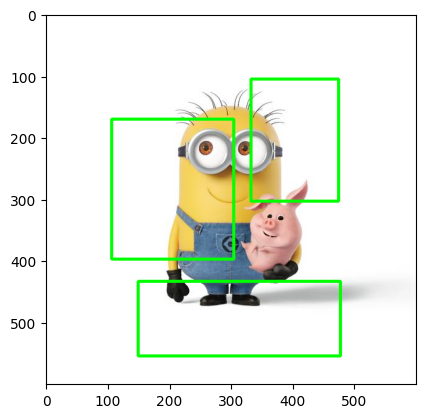

[[(106, 170), (304, 397)], [(332, 105), (474, 303)], [(477, 433), (149, 554)]]


In [ ]:
# Mouse callback function to draw bounding boxes
def annotate_image(event, x, y, flags, param):
    global start_point, points, drawing, image, temp_image

    if event == cv2.EVENT_LBUTTONDOWN:
        # Save starting point when left mouse button is pressed
        start_point = (x, y)
        drawing = True

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            # Draw temporary rectangle while dragging
            temp_image = image.copy()
            cv2.rectangle(temp_image, start_point, (x, y), (120, 255, 0), 2)
            cv2.imshow("image", temp_image)

    elif event == cv2.EVENT_LBUTTONUP:
        # Save final rectangle coordinates
        points.append([start_point, (x, y)])
        cv2.rectangle(image, start_point, (x, y), (0, 255, 0), 3)
        cv2.imshow("image", image)
        drawing = False

# Load imag
image = cv2.imread("minion.jpg")
clone = image.copy()       # Backup for reset
temp_image = image.copy()  # Temporary image for drawing preview

# Create window and set mouse callback
cv2.namedWindow("image")
cv2.setMouseCallback("image", annotate_image)

# Main display loop
while True:
    cv2.imshow("image", image if not drawing else temp_image)
    key = cv2.waitKey(5) & 0xFF

    if key == ord("r"):
        # Reset image and annotation
        image = clone.copy()
        points = []

    elif key == 27:
        # Exit on ESC key
        break

cv2.destroyAllWindows()
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
print(points)

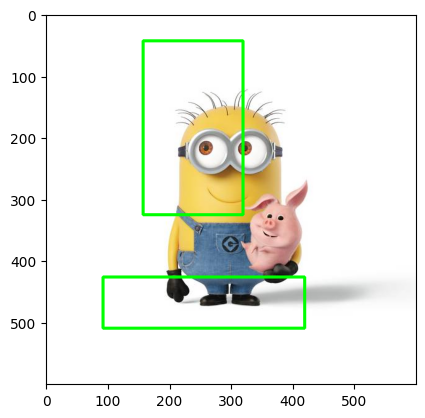

[[(157, 43), (319, 325)], [(92, 426), (419, 509)]]


In [ ]:
import cv2

start_point=(0,0)
points=[]
drawing=False

# Mouse callback for drawing rectangles
def annotate_image_with_undo(event,x,y,flags,param):
    global start_point,points,drawing
    if event==cv2.EVENT_LBUTTONDOWN:
        # Start drawing
        start_point=(x,y)
        drawing=True
    elif  event==cv2.EVENT_MOUSEMOVE:
        if drawing:
            # Show temporary rectangle while dragging
            temp_image=image.copy()
            cv2.rectangle(temp_image,start_point,(x,y),(0,250,0),2)
            cv2.imshow("image",temp_image)
            drawing=False
    elif event==cv2.EVENT_LBUTTONUP:
        # Save rectangle and draw it permanently
        points.append([start_point,(x,y)])
        cv2.rectangle(image,start_point,(x,y),(0,255,0),4)
        cv2.imshow("image",image)
        drawing=False
image=cv2.imread("minion.jpg")
clone=image.copy()
temp_image=image.copy()
cv2.namedWindow("image")
cv2.setMouseCallback("image", annotate_image_with_undo)

while True:
    if drawing==False:
        cv2.imshow("image",image)
    key=cv2.waitKey(5)&0xFF

    if key==ord("r"):
        # Reset all boxes
        image=clone.copy()
        points=[]
        # Undo last box
    elif key==ord("z"):
        image=clone.copy()
        points.pop()
        for p in points:
            cv2.rectangle(image,p[0],p[1],(0,250,0),3)

    elif key==27:
        break
    
cv2.destroyAllWindows()
# Show final result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
print(points)

